## Imports

In [2]:
import os
import random
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np

from autoencoder_funs import compare_training_losses, show_dataloader_batch, plot_training_loss, train_autoencoder, check_reconstructions, evaluate_autoencoder
from autoencoder_models import HeavyweightCrackAutoencoder, LightweightCrackAutoencoder, CrackAutoencoder

## Cuda check

In [3]:
CUDA = True
device = "cuda" if (torch.cuda.is_available() and CUDA) else "cpu"
print(torch.cuda.is_available())
print(device)

True
cuda


In [4]:
os.environ['KAGGLE_USERNAME'] = "sondrekristiansen"
os.environ['KAGGLE_KEY'] = "sorrebus"

print("Downloading Concrete Crack dataset...")
!kaggle datasets download -d arnavr10880/concrete-crack-images-for-classification

print("Unzipping files...")
!unzip -q concrete-crack-images-for-classification.zip -d ./concrete_data

print("Download and extraction complete! Ready for PyTorch.")

Dataset URL: https://www.kaggle.com/datasets/arnavr10880/concrete-crack-images-for-classification
License(s): Attribution 4.0 International (CC BY 4.0)
100% 233M/233M [00:01<00:00, 185MB/s]  

Unzipping files...
Download and extraction complete! Ready for PyTorch.


## Seeding

In [5]:
def seed_everything(seed: int) -> None:
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

## Load dataset

In [7]:
class ConcreteDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'image_path']
        label = self.df.loc[idx, 'label']
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.float32)

if __name__ == '__main__':
    
    # UPDATE THIS TO YOUR EXACT LOCAL FOLDER PATH
    DATA_DIR = './concrete_data/' 

    neg_folder = os.path.join(DATA_DIR, 'Negative')
    pos_folder = os.path.join(DATA_DIR, 'Positive')
    negative_paths = [os.path.join(neg_folder, f) for f in os.listdir(neg_folder) if f.endswith('.jpg')]
    positive_paths = [os.path.join(pos_folder, f) for f in os.listdir(pos_folder) if f.endswith('.jpg')]

    num_positive = int(len(positive_paths) * 0.2)
    
    seed_everything(42)
    positive_paths = random.sample(positive_paths, num_positive)


    neg_data = [{'image_path': path, 'label': 0} for path in negative_paths]
    pos_data = [{'image_path': path, 'label': 1} for path in positive_paths]
    df_pos = pd.DataFrame(pos_data)
    df_neg = pd.DataFrame(neg_data)
    print(f"Dataset Balanced! Using {len(negative_paths)} Normal images and {len(positive_paths)} Crack images.")


    train_df, temp_df = train_test_split(df_neg, test_size=0.50, stratify=df_neg['label']) # Train on normal only
    val_df, test_df = train_test_split(pd.concat([df_pos, temp_df]), test_size=0.50, stratify=pd.concat([df_pos, temp_df])['label'])

    # test_df = pd.read_csv('concrete_test_split.csv')
    
    print(f"Split sizes -> Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    print(f"Distribution of labels in Train: {train_df['label'].value_counts().to_dict()}")
    print(f"Distribution of labels in Val: {val_df['label'].value_counts().to_dict()}")
    print(f"Distribution of labels in Test: {test_df['label'].value_counts().to_dict()}")

    train_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ToTensor()
    ])

    test_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    train_dataset = ConcreteDataset(train_df, transform=train_transforms)
    val_dataset = ConcreteDataset(val_df, transform=test_transforms)
    test_dataset = ConcreteDataset(test_df, transform=test_transforms)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

Dataset Balanced! Using 20000 Normal images and 4000 Crack images.
Split sizes -> Train: 10000 | Val: 7000 | Test: 7000
Distribution of labels in Train: {0: 10000}
Distribution of labels in Val: {0: 5000, 1: 2000}
Distribution of labels in Test: {0: 5000, 1: 2000}


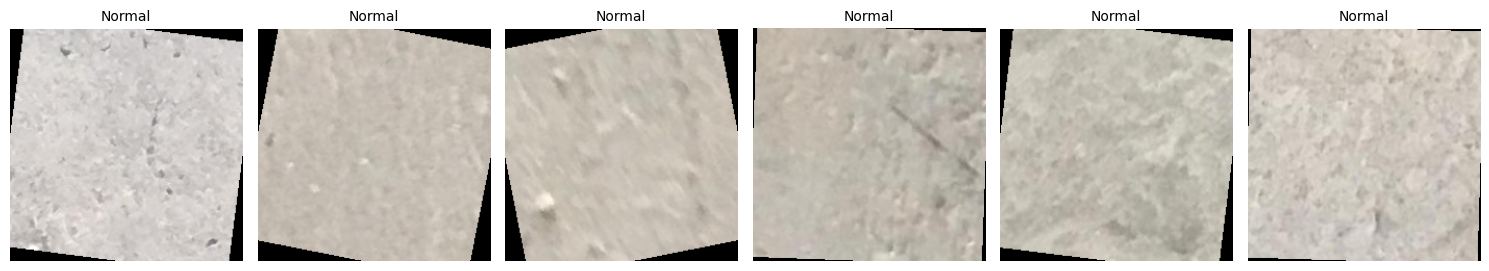

In [8]:
show_dataloader_batch(train_loader)

## Load weights if saved

In [9]:
try: 
    inference_model = HeavyweightCrackAutoencoder()

    weights_path = 'heavyweight_autoencoder.pth'
    inference_model.load_state_dict(torch.load(weights_path, map_location=torch.device('cpu')))

    inference_model.eval()

    # Move to GPU if available
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    inference_model = inference_model.to(device)
except:
    print("Could not retrieve saved weights.")

Could not retrieve saved weights.


## Training

Starting Training...
Epoch [01/5] | Train Loss: 0.0171
Epoch [02/5] | Train Loss: 0.0039
Epoch [03/5] | Train Loss: 0.0030
Epoch [04/5] | Train Loss: 0.0027
Epoch [05/5] | Train Loss: 0.0024

 Training Complete!
Starting Training...
Epoch [01/5] | Train Loss: 0.0444
Epoch [02/5] | Train Loss: 0.0226
Epoch [03/5] | Train Loss: 0.0172
Epoch [04/5] | Train Loss: 0.0160
Epoch [05/5] | Train Loss: 0.0154

 Training Complete!
Starting Training...
Epoch [01/5] | Train Loss: 0.0227
Epoch [02/5] | Train Loss: 0.0057
Epoch [03/5] | Train Loss: 0.0034
Epoch [04/5] | Train Loss: 0.0026
Epoch [05/5] | Train Loss: 0.0023

 Training Complete!


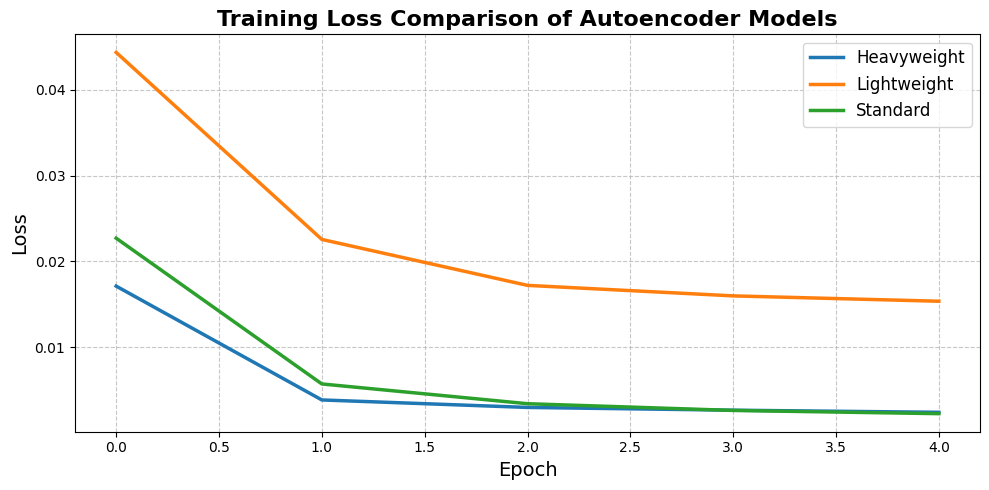

In [10]:
EPOCHS = 5
learning_rate = 1e-4

heavy_model = HeavyweightCrackAutoencoder()
light_model = LightweightCrackAutoencoder()
standard_model = CrackAutoencoder()
criterion = nn.MSELoss()

heavy_loss = train_autoencoder(heavy_model, train_loader, criterion, learning_rate, EPOCHS, device)
light_loss = train_autoencoder(light_model, train_loader, criterion, learning_rate, EPOCHS, device)
standard_loss = train_autoencoder(standard_model, train_loader, criterion, learning_rate, EPOCHS, device)

loss_dict = {
    "Heavyweight": heavy_loss,
    "Lightweight": light_loss,
    "Standard": standard_loss
}

compare_training_losses(loss_dict)


Running Validation Set with Top-K% Anomaly Scoring...

 Evaluation Complete!
Final AUROC Score: 0.9955


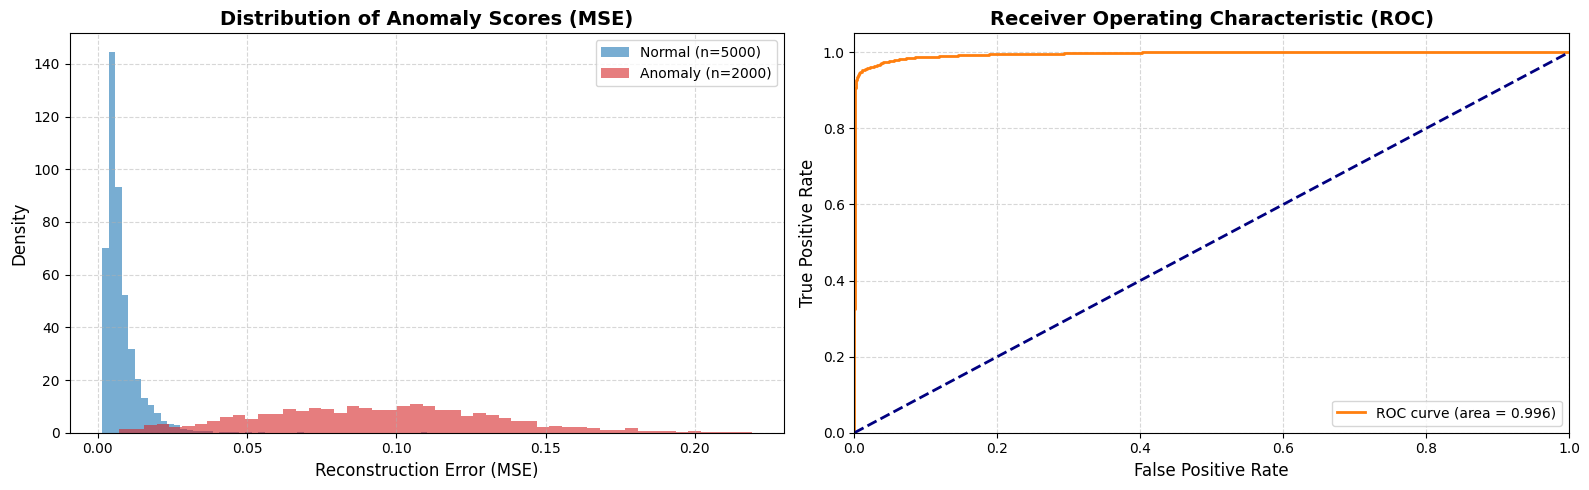

Mathematical Optimal Anomaly Threshold (MSE): 0.026255

Final Model Accuracy: 97.64%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      5000
     Anomaly       0.96      0.96      0.96      2000

    accuracy                           0.98      7000
   macro avg       0.97      0.97      0.97      7000
weighted avg       0.98      0.98      0.98      7000



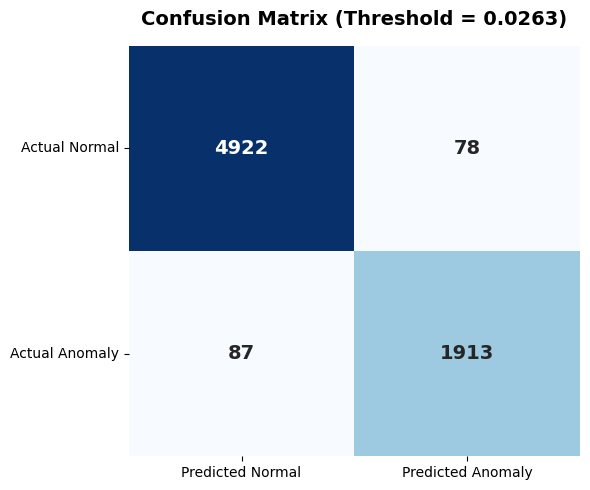

Running Validation Set with Top-K% Anomaly Scoring...

 Evaluation Complete!
Final AUROC Score: 0.9946


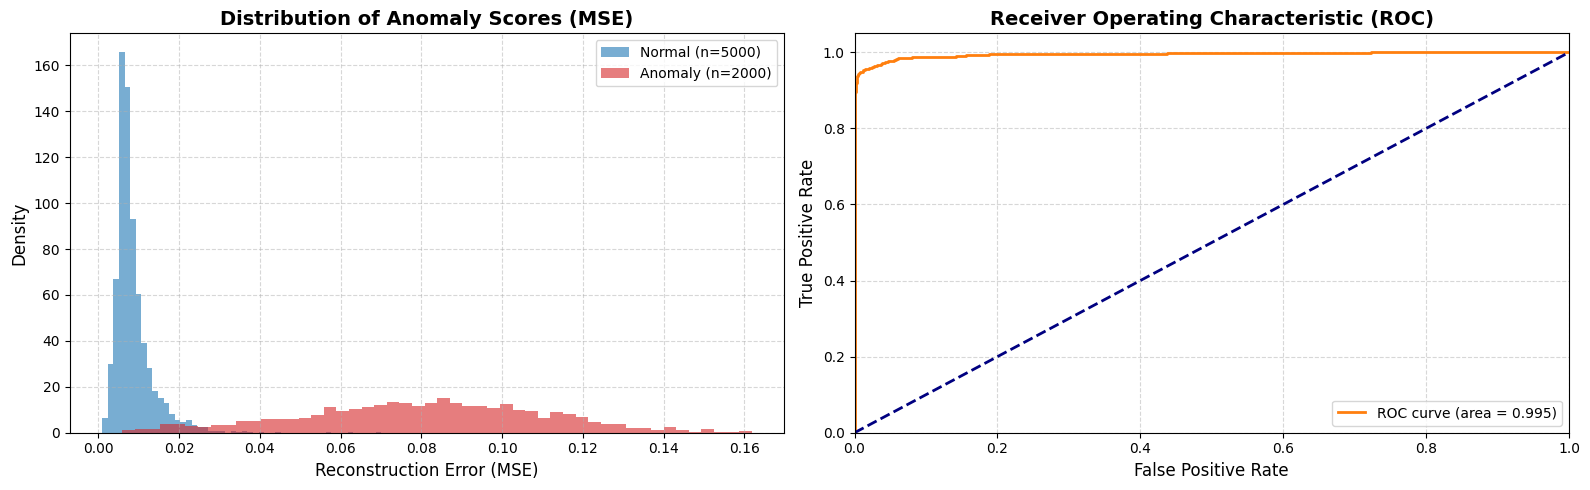

Mathematical Optimal Anomaly Threshold (MSE): 0.024645

Final Model Accuracy: 97.74%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98      5000
     Anomaly       0.97      0.95      0.96      2000

    accuracy                           0.98      7000
   macro avg       0.97      0.97      0.97      7000
weighted avg       0.98      0.98      0.98      7000



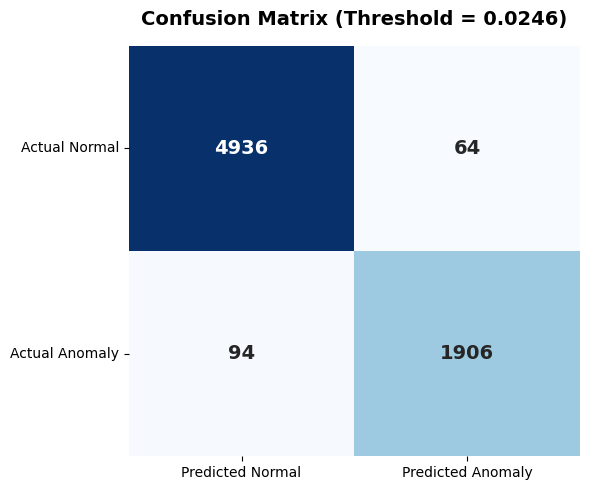

Running Validation Set with Top-K% Anomaly Scoring...

 Evaluation Complete!
Final AUROC Score: 0.9963


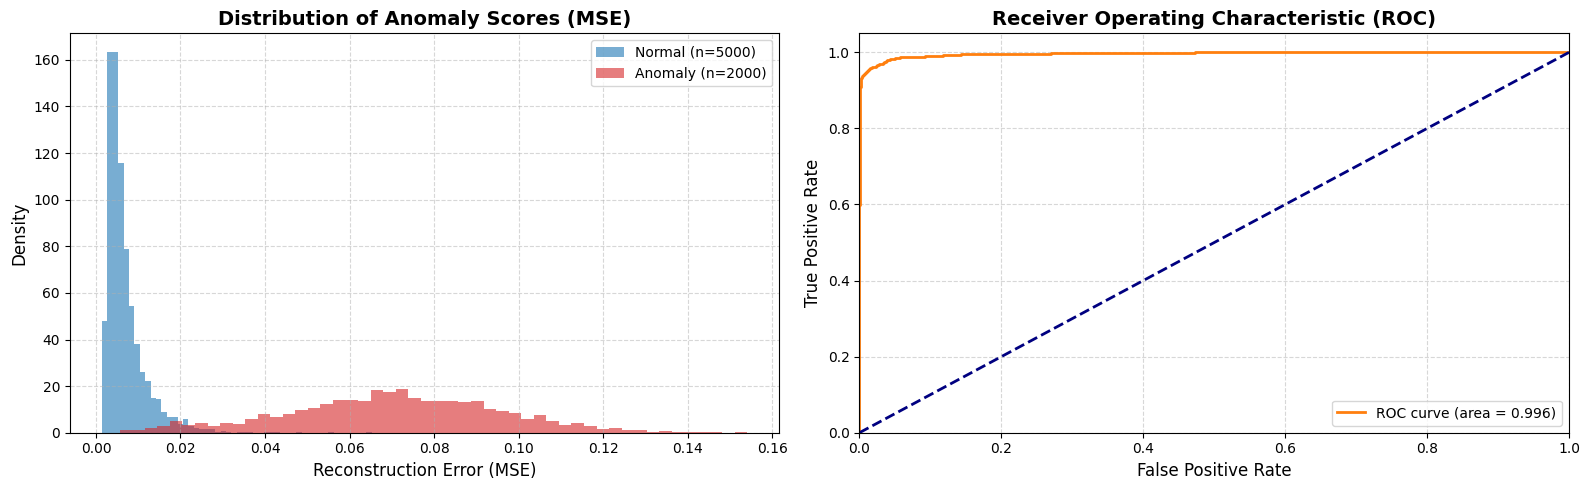

Mathematical Optimal Anomaly Threshold (MSE): 0.022771

Final Model Accuracy: 97.79%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98      5000
     Anomaly       0.97      0.96      0.96      2000

    accuracy                           0.98      7000
   macro avg       0.97      0.97      0.97      7000
weighted avg       0.98      0.98      0.98      7000



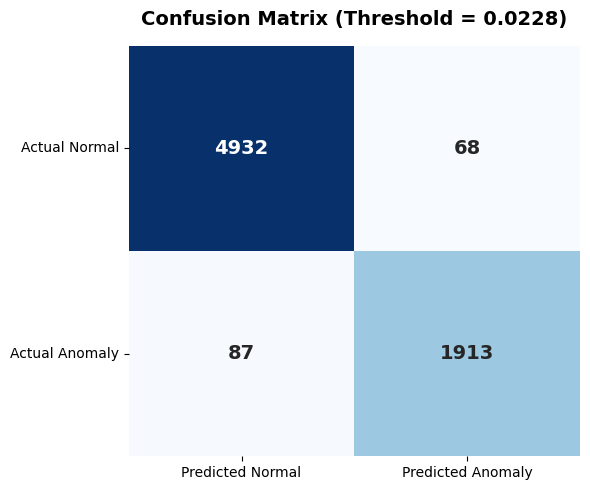

In [11]:
evaluate_autoencoder(heavy_model, val_loader, criterion, device)
evaluate_autoencoder(light_model, val_loader, criterion, device)
evaluate_autoencoder(standard_model, val_loader, criterion, device)

Running Validation Set with Top-K% Anomaly Scoring...

 Evaluation Complete!
Final AUROC Score: 0.9962


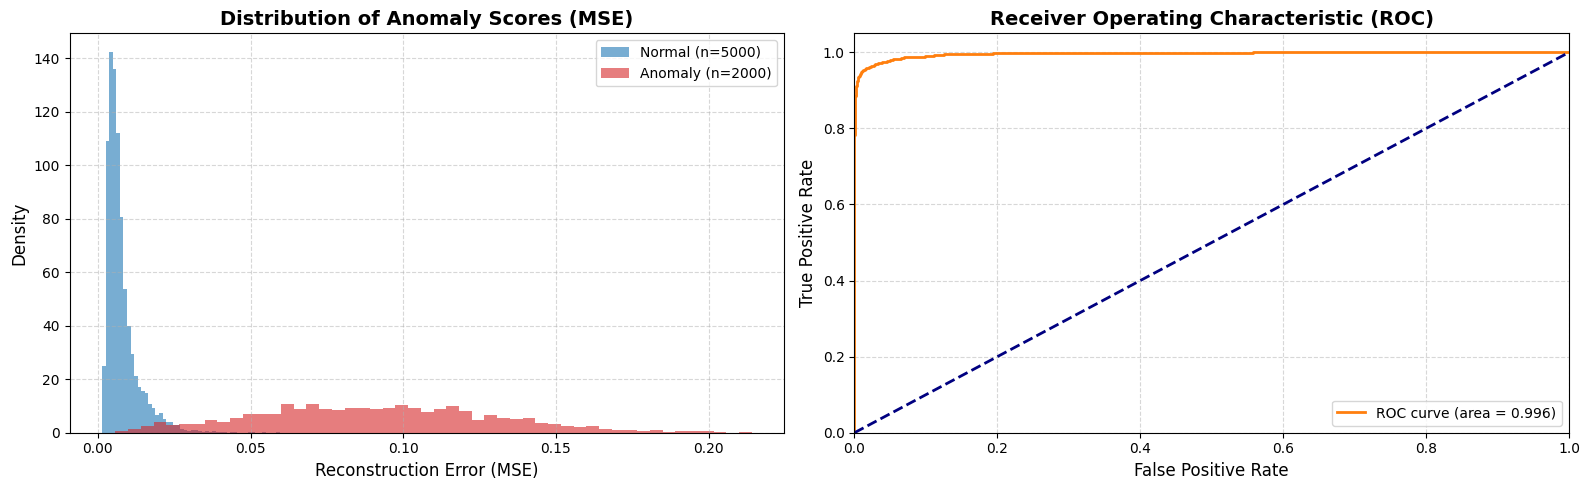

Mathematical Optimal Anomaly Threshold (MSE): 0.025310

Final Model Accuracy: 97.63%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      5000
     Anomaly       0.96      0.96      0.96      2000

    accuracy                           0.98      7000
   macro avg       0.97      0.97      0.97      7000
weighted avg       0.98      0.98      0.98      7000



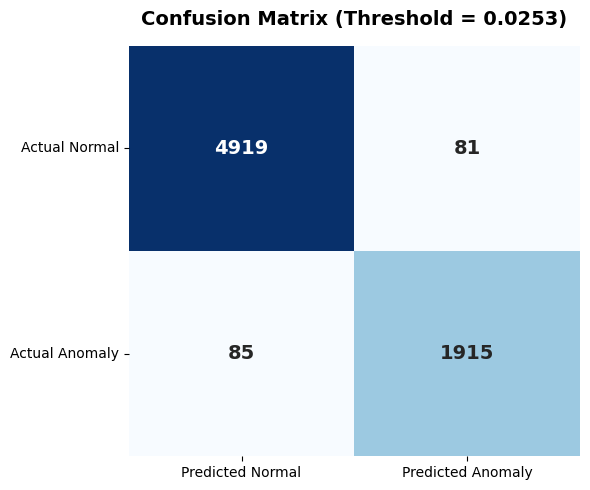

Running Validation Set with Top-K% Anomaly Scoring...

 Evaluation Complete!
Final AUROC Score: 0.9959


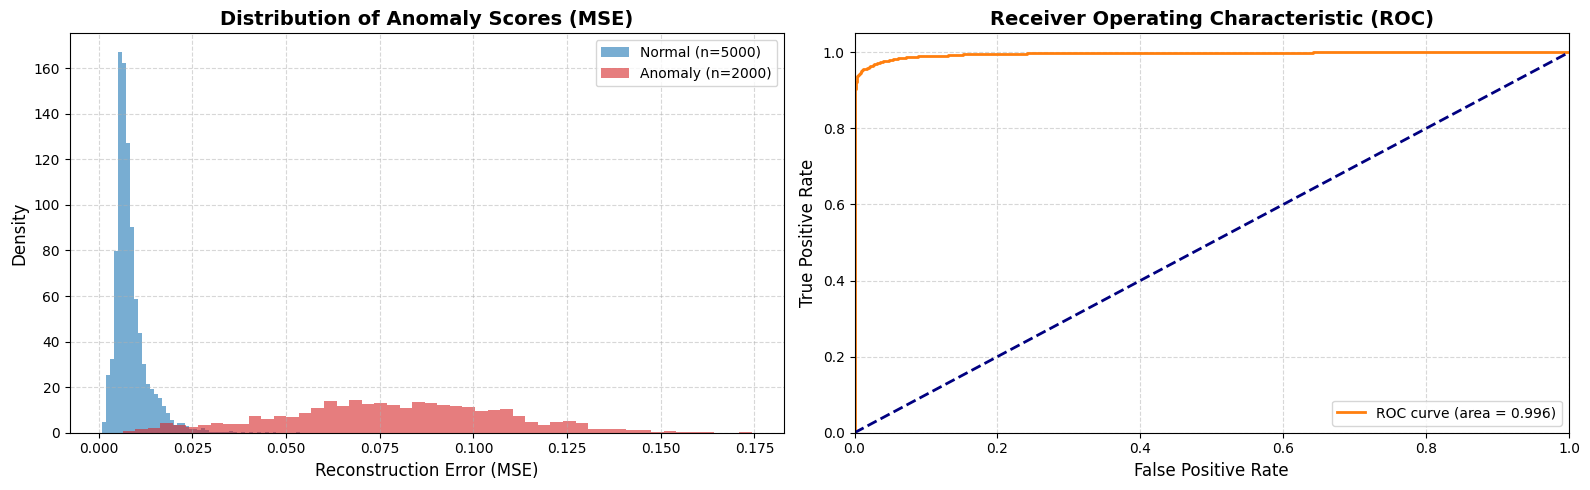

Mathematical Optimal Anomaly Threshold (MSE): 0.024004

Final Model Accuracy: 97.80%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98      5000
     Anomaly       0.97      0.95      0.96      2000

    accuracy                           0.98      7000
   macro avg       0.97      0.97      0.97      7000
weighted avg       0.98      0.98      0.98      7000



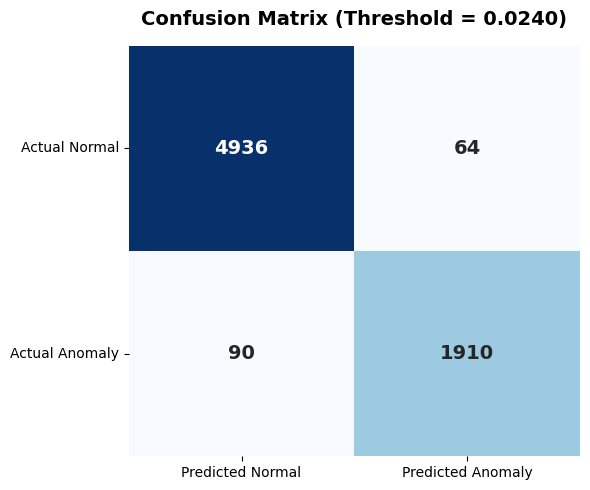

Running Validation Set with Top-K% Anomaly Scoring...

 Evaluation Complete!
Final AUROC Score: 0.9971


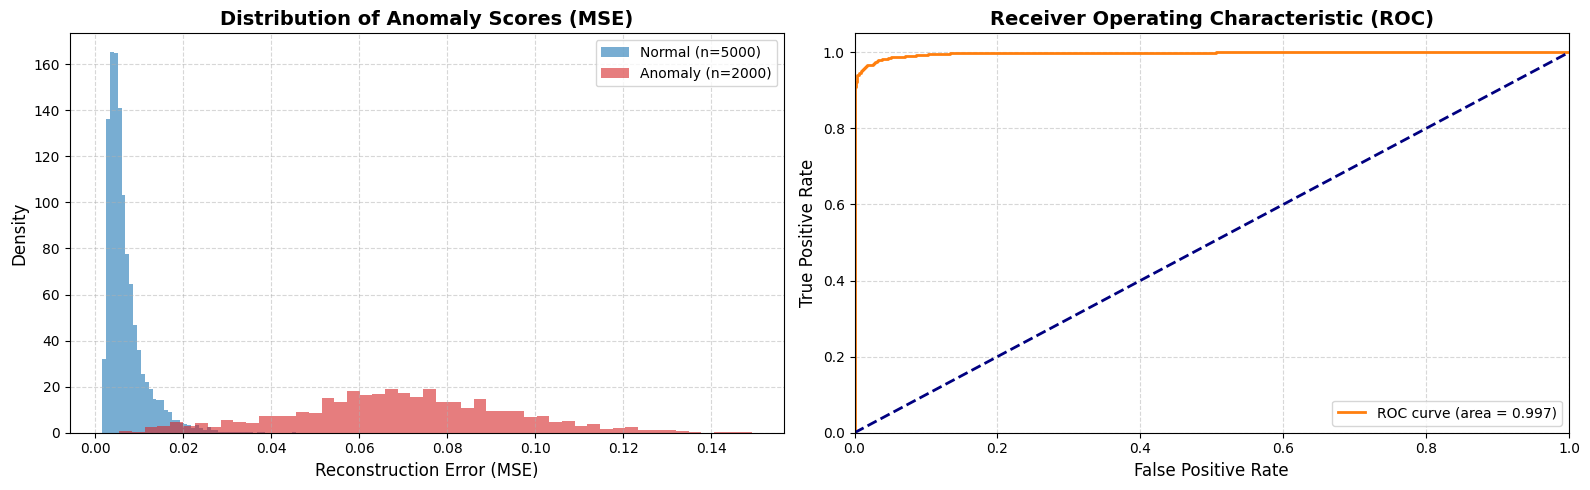

Mathematical Optimal Anomaly Threshold (MSE): 0.021179

Final Model Accuracy: 97.76%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.98      5000
     Anomaly       0.96      0.97      0.96      2000

    accuracy                           0.98      7000
   macro avg       0.97      0.97      0.97      7000
weighted avg       0.98      0.98      0.98      7000



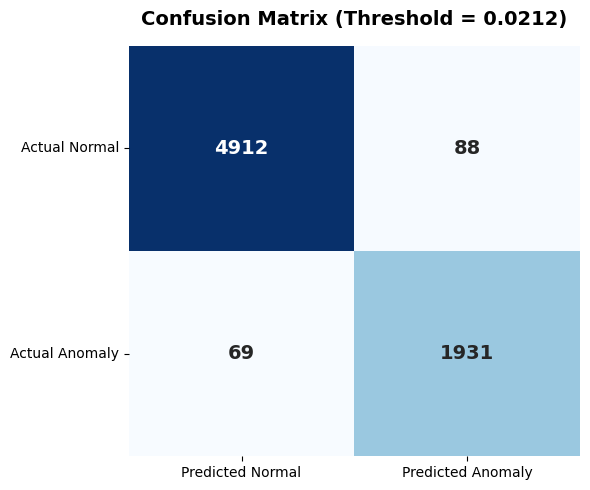

In [12]:
evaluate_autoencoder(heavy_model, test_loader, criterion, device)
evaluate_autoencoder(light_model, test_loader, criterion, device)
evaluate_autoencoder(standard_model, test_loader, criterion, device)

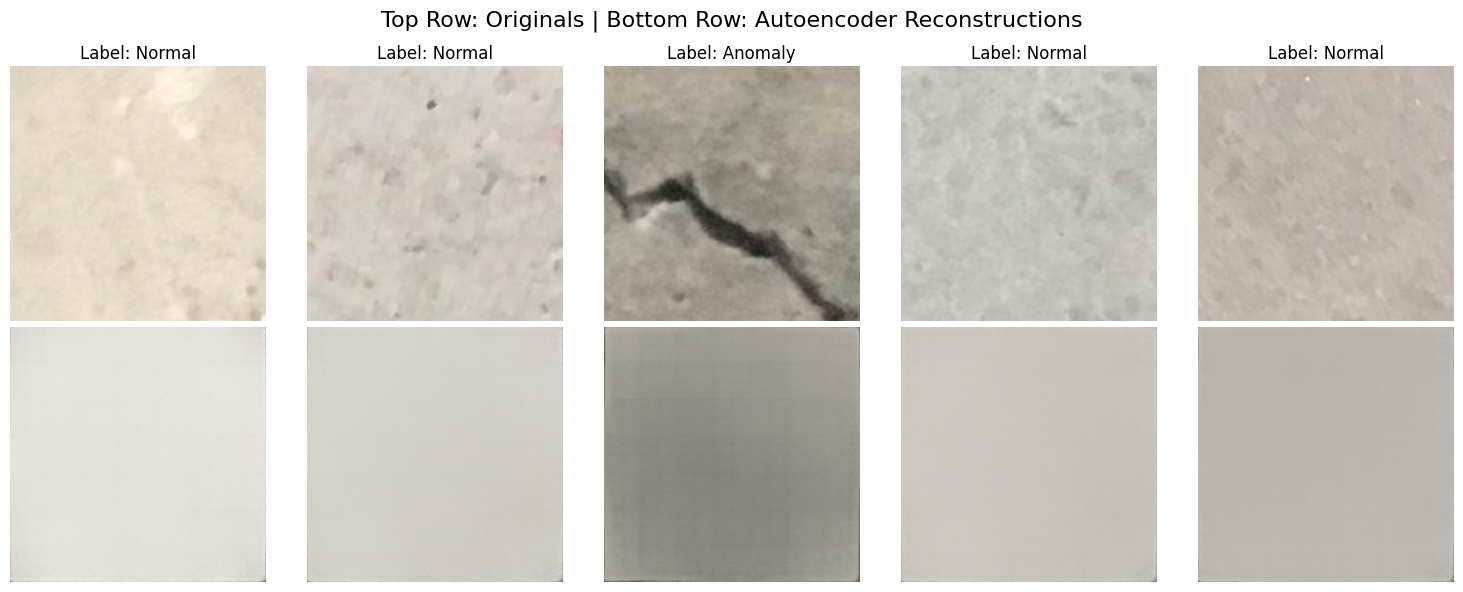

In [13]:
check_reconstructions(heavy_model, test_loader, device)

## Save model weights

In [14]:
torch.save(heavy_model.state_dict(), 'heavyweight_autoencoder.pth')
torch.save(standard_model.state_dict(), 'standard_autoencoder.pth')
torch.save(light_model.state_dict(), 'lightweight_autoencoder.pth')